## Hands ON

Uma empresa do ramo alimentício tem mais de 20 mil colaboradores em todo o Brasil. Com o passar dos anos a empresa percebeu um aumento no custo do plano de saúde com seus colaboradores. Como forma de entender esse comportamento, a gerência de Benefícios e Bem Estar da Diretoria de Pessoas conduziu uma pesquisa interna com um grupo de 1.338 colaboradores sorteados aleatoriamente ao longo de um ano.

A gerência acredita que fatores como fumo e obesidade podem estar relacionados com o maior uso do plano de saúde, o que acaba elevando os custos. Portanto, os colaboradores da pesquisa responderam características pessoais como o Índice de Massa Corpórea (IMC), Qte de Filhos e se fazem uso de cigarros. Segue abaixo o dicionário dos dados:

#### Dicionário de dados

| Variável | Descrição |
| ------ | ------ |
| DtRef | Data de Referência quando a pesquisa com o colaborador foi realizada |
| Idade | Idade do colaborador |
| Sexo | Sexo do colaborador |
| IMC | Índice de Massa Corporal do colaborador |
| Qte_filhos | Qte de filhos que o colaborador tem |
| Fumante | Flag se o colaborador é fumante ou não fumante |
| Regiao | Região do Brasil onde o colaborador mora |
| Custo_Saude | Custo de Plano de Saúde que esse colaborador trouxe para a empresa 3 meses depois da Data de Referência|

## 1. Importando Bibliotecas

In [470]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#modelo a ser treinado
from sklearn import linear_model

#métrica de performance
from sklearn.metrics import mean_squared_error, r2_score

#particionamento
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings("ignore")

### 1.1 Carregando Dados

In [471]:
df = pd.read_excel('../../data/base_custos_saude.xlsx')
df.head()

,DtRef,Idade,Sexo,IMC,Qte_Filhos,Fumante,Regiao,Custo_Saude
0,202101,25,Masculino,26.220,0,Não,Nordeste,272.132080
1,202101,23,Masculino,17.385,1,Não,Norte,277.519215
2,202101,41,Masculino,21.780,1,Não,Sudeste,627.247720
3,202101,38,Masculino,37.050,1,Não,Nordeste,607.967150
4,202101,60,Feminino,24.530,0,Não,Sudeste,1262.989670


## 2. Limpeza e Preparação

### 2.1 Visão Geral

In [472]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DtRef        1338 non-null   int64  
 1   Idade        1338 non-null   int64  
 2   Sexo         1338 non-null   str    
 3   IMC          1338 non-null   float64
 4   Qte_Filhos   1338 non-null   int64  
 5   Fumante      1338 non-null   str    
 6   Regiao       1338 non-null   str    
 7   Custo_Saude  1338 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB


### 2.2 Atribuindo o tipo correto de dado à coluna "DtRef" (int -> datetime)

In [473]:
##df['DtRef'] = pd.to_datetime(df['DtRef'], format="%Y%m")

In [474]:
#df['DtRef'].value_counts()

### 2.3 Verificando se há valores faltantes ou duplicados

In [475]:
df.isna().sum()

DtRef          0
Idade          0
Sexo           0
IMC            0
Qte_Filhos     0
Fumante        0
Regiao         0
Custo_Saude    0
dtype: int64

In [476]:
df.duplicated().sum()

np.int64(0)

### 2.4 Analisando se as medidas resumo fazem sentido

In [477]:
df.describe()

,DtRef,Idade,IMC,Qte_Filhos,Custo_Saude
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,202106.503737,39.207025,30.663397,1.094918,1327.042227
std,3.428562,14.049960,6.098187,1.205493,1211.001124
min,202101.000000,18.000000,15.960000,0.000000,112.187390
25%,202104.000000,27.000000,26.296250,0.000000,474.028715
50%,202106.000000,39.000000,30.400000,1.000000,938.203300
75%,202109.000000,51.000000,34.693750,2.000000,1663.991252
max,202112.000000,64.000000,53.130000,5.000000,6377.042801


## 3. Análise Exploratória

### 3.1 Analisando a correlação entre as variáveis quantitativas

<Axes: >

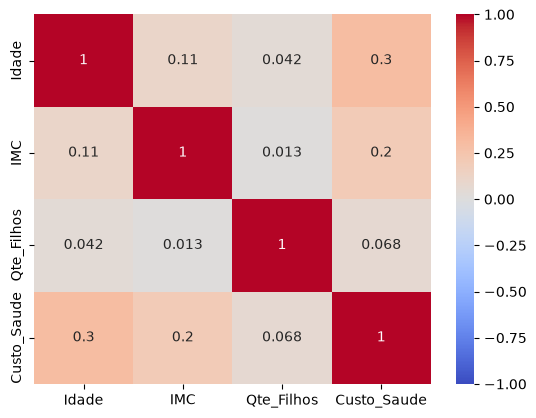

In [478]:
sns.heatmap(df.drop(columns=['DtRef', 'Sexo', 'Fumante', 'Regiao']).corr(), vmin=-1, vmax=1, annot=True, cmap='coolwarm')

### 3.2 Buscando um padrão entre o custo de saude e as demais variáveis

Text(0.5, 1.0, 'Custo x Qte de Filhos')

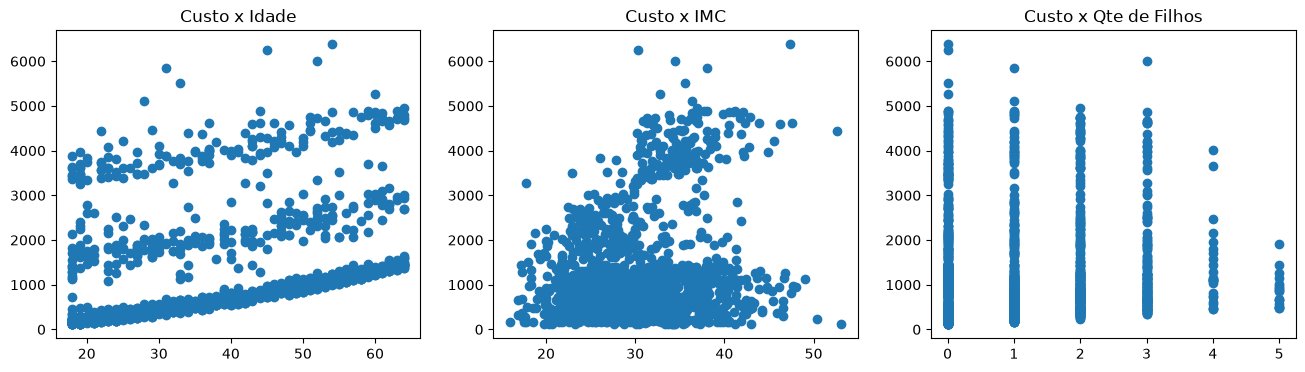

In [479]:
fig, axes = plt.subplots(1,3, figsize=(16,4))

axes[0].scatter(df['Idade'], df['Custo_Saude'])
axes[0].set_title('Custo x Idade')

axes[1].scatter(df['IMC'], df['Custo_Saude'])
axes[1].set_title('Custo x IMC')

axes[2].scatter(df['Qte_Filhos'], df['Custo_Saude'])
axes[2].set_title('Custo x Qte de Filhos')

O custo de saude tem pouca correlação com as variáveis numéricas, mas e as categóricas?

<Axes: xlabel='Idade', ylabel='Custo_Saude'>

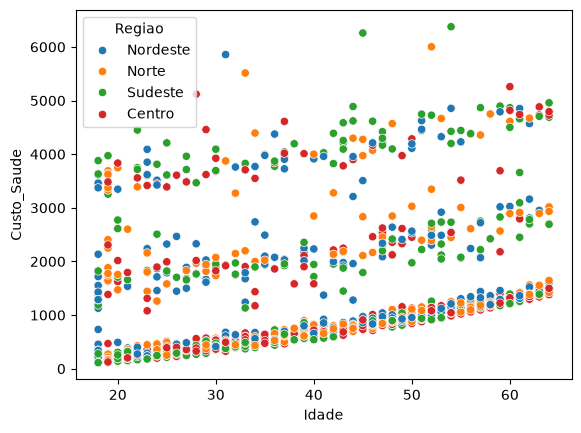

In [480]:
sns.scatterplot(x=df['Idade'], y=df['Custo_Saude'], hue=df['Regiao'])

<Axes: xlabel='Idade', ylabel='Custo_Saude'>

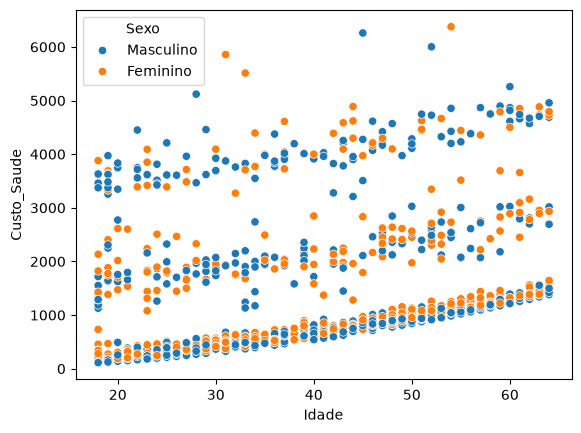

In [481]:
sns.scatterplot(x=df['Idade'], y=df['Custo_Saude'], hue=df['Sexo'])

<Axes: xlabel='Idade', ylabel='Custo_Saude'>

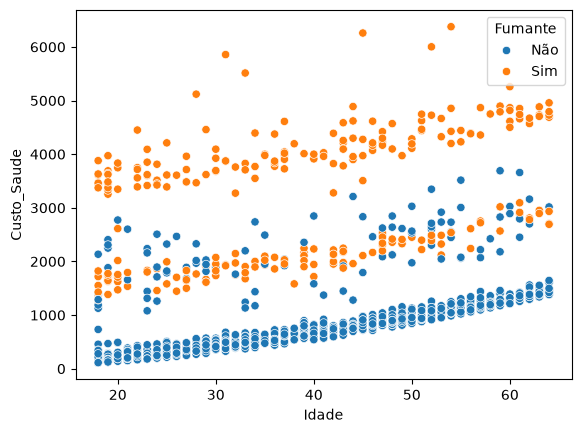

In [482]:
sns.scatterplot(x=df['Idade'], y=df['Custo_Saude'], hue=df['Fumante'])

Nota-se que os colaboradores que fumam têm um custo de saúde maior que o daqueles que não são fumantes

## 4. Desenvolvendo o modelo

### 4.1 Definindo as *features* e o *target*

In [483]:
y = df['Custo_Saude']

x = df[['Idade', 'Sexo', 'IMC', 'Qte_Filhos', 'Fumante', 'Regiao']]

### 4.2 Criando as variáveis *dummy* para as features qualitativas

In [484]:
x = pd.get_dummies(x, drop_first=True)

### 4.3 Validação Out of Sample 


In [485]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=50)

In [486]:
modelo = linear_model.LinearRegression(fit_intercept=True)
modelo.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 24.72, 33.67, 58.96,..., 43.39, 51.98,-54.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Idade','IMC','Qte_Filhos',...,'Regiao_Nordeste','Regiao_Norte', 'Regiao_Sudeste']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1236
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [487]:
pd.DataFrame({'Variáveis': x_train.columns, 'Betas': modelo.coef_})

,Variáveis,Betas
0,Idade,24.718403
1,IMC,33.669597
2,Qte_Filhos,58.957392
3,Sexo_Masculino,-26.682137
4,Fumante_Sim,2389.734268
5,Regiao_Nordeste,43.389732
6,Regiao_Norte,51.983317
7,Regiao_Sudeste,-54.283788


In [488]:
custo_estimado_treino = modelo.predict(x_train)
r2_treino = r2_score(y_train, custo_estimado_treino)

custo_estimado_teste = modelo.predict(x_test)
r2_teste = r2_score(y_test, custo_estimado_teste)

pd.DataFrame({'R2 em Treino':r2_treino , 'R2 em Teste': r2_teste},[0])

,R2 em Treino,R2 em Teste
0,0.75165,0.74665


### 4.4 Validação Cruzada - KFold

In [489]:
particoes = KFold(n_splits=5, shuffle=True, random_state=42)

In [490]:
r2_train = []
r2_test = []

for train_i, test_i in particoes.split(x):
    
    x_train, x_test = x.iloc[train_i], x.iloc[test_i]
    y_train, y_test = y.iloc[train_i], y.iloc[test_i]
    
    modelo = linear_model.LinearRegression(fit_intercept=True)
    modelo.fit(x_train, y_train)
    
    custo_estimado_treino = modelo.predict(x_train)
    custo_estimado_teste = modelo.predict(x_test)
    
    r2_train.append(r2_score(y_train, custo_estimado_treino))
    r2_test.append(r2_score(y_test, custo_estimado_teste))
    
resultado = pd.DataFrame({'R2 em Treino':r2_train , 'R2 em Teste': r2_test})
resultado

,R2 em Treino,R2 em Teste
0,0.752771,0.740228
1,0.750053,0.754157
2,0.757518,0.715936
3,0.743434,0.775681
4,0.753532,0.734160


In [491]:
resultado.describe().loc[['mean','std']]

,R2 em Treino,R2 em Teste
mean,0.751462,0.744032
std,0.005223,0.022392


### 4.5 Validação Out of Time

In [492]:
df['DtRef'].value_counts().sort_index()

DtRef
202101    105
202102    112
202103    107
202104    122
202105    114
202106    117
202107    101
202108    115
202109    119
202110    102
202111    114
202112    110
Name: count, dtype: int64

como temos 1 anos de base, vamos usar 70% pra treino e o restante para teste

In [493]:
12*0.7

8.399999999999999

In [494]:
df_dummies = pd.get_dummies(df,drop_first=True)

In [495]:
df_train = df_dummies[df_dummies['DtRef'] <= 202108].copy()
df_test = df_dummies[df_dummies['DtRef'] > 202108].copy()

In [496]:
x_treino = df_train.drop(columns=['DtRef', 'Custo_Saude'])
y_treino = df_train['Custo_Saude']

x_teste = df_test.drop(columns=['DtRef', 'Custo_Saude'])
y_teste = df_test['Custo_Saude']

In [497]:
modelo = linear_model.LinearRegression(fit_intercept=True)

modelo.fit(x_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[25.14,31.8 ,48.89,...,94.93,92.49,-5.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Idade','IMC','Qte_Filhos',...,'Regiao_Nordeste','Regiao_Norte', 'Regiao_Sudeste']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1188
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [498]:
pd.DataFrame({'Variáveis': x_treino.columns, 'Betas': modelo.coef_})

,Variáveis,Betas
0,Idade,25.142540
1,IMC,31.804968
2,Qte_Filhos,48.894520
3,Sexo_Masculino,-34.764725
4,Fumante_Sim,2282.573503
5,Regiao_Nordeste,94.925033
6,Regiao_Norte,92.486954
7,Regiao_Sudeste,-5.951687


In [511]:
custo_estimado_treino = modelo.predict(x_treino)
custo_estimado_teste = modelo.predict(x_teste)

r2_Treino = r2_score(y_treino, custo_estimado_treino)
r2_Teste = r2_score(y_teste, custo_estimado_teste)

r2_OoT = pd.DataFrame({'R2 Treino': r2_Treino, 'R2 Teste': r2_Teste}, [0])
r2_OoT

,R2 Treino,R2 Teste
0,0.730722,0.780252


#### Out of Time - Evolução do R² ao longo do tempo

In [500]:
df_dummies['Custo_Saude_Estimado'] = modelo.predict(df_dummies.drop(columns=['Custo_Saude','DtRef']))

In [504]:
r2_por_ano_mes = {}

for anomes in df['DtRef'].unique():
    df_anomes = df_dummies[df_dummies['DtRef'] == anomes]
    r2 = r2_score(df_anomes['Custo_Saude'],df_anomes['Custo_Saude_Estimado'])
    r2_por_ano_mes.update( {anomes : r2} )
    
df_r2_por_ano_mes = pd.DataFrame(r2_por_ano_mes,[0]).T.rename(columns={0: 'R2'})

In [505]:
df_r2_por_ano_mes

,R2
202101,0.685620
202102,0.769540
202103,0.670654
202104,0.706893
202105,0.724774
202106,0.807934
202107,0.673710
202108,0.770771
202109,0.783540
202110,0.780874


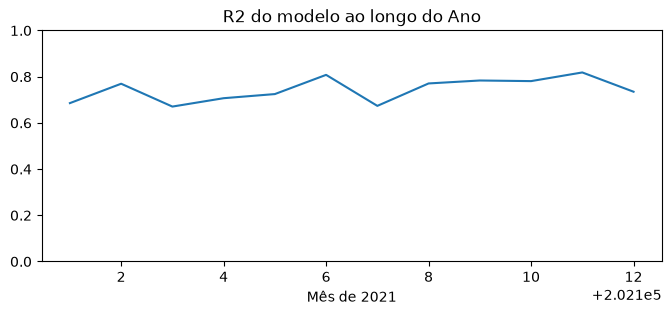

In [508]:
plt.figure(figsize=(8,3))
plt.plot(df_r2_por_ano_mes['R2'])
plt.ylim(bottom=0,top=1);

plt.title("R2 do modelo ao longo do Ano");
plt.xlabel("Mês de 2021");

## 5. Comparando os Resultados

### 5.1 Validação Cruzada - KFold = 5

In [509]:
resultado

,R2 em Treino,R2 em Teste
0,0.752771,0.740228
1,0.750053,0.754157
2,0.757518,0.715936
3,0.743434,0.775681
4,0.753532,0.734160


### 5.2 Validação Out of Time - 8 meses de treino 3 de teste

In [512]:
r2_OoT

,R2 Treino,R2 Teste
0,0.730722,0.780252


O melhor é Out of Time devido à natureza dos dados mas é bom usar o KFold para corroborar a decisão e passar mais segurança.